In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = datasets.load_breast_cancer()
X = data.data
y = data.target

# Load the dataset
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(df.head())
print('Shape of the Dataset : ',df.shape)
print('Target names : ',data.target_names)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [3]:
# Check for null values
print(df.isnull().sum())

# Checking for duplicate values
print(df.duplicated().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
0


In [4]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

svm_model = SVC(kernel='rbf', C=0.1, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

,C,0.1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [5]:
# Prediction
y_pred = svm_model.predict(X_test)

# Accuracy
print('Training Accuracy : ',svm_model.score(X_train, y_train))
print('Test Accuracy : ',svm_model.score(X_test, y_test))

Training Accuracy :  0.9582417582417583
Test Accuracy :  0.9473684210526315


In [6]:
print('Classification report :\n',classification_report(y_test, y_pred, target_names=data.target_names))

Classification report :
               precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



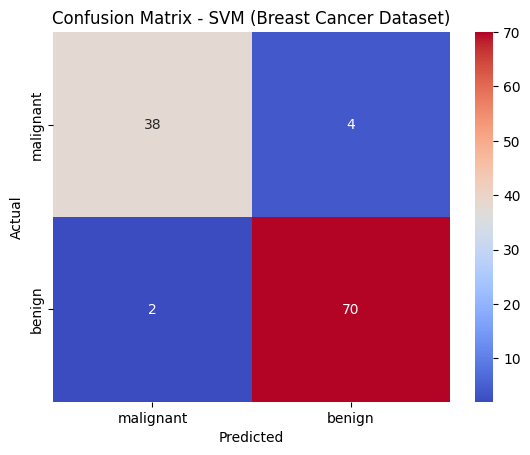

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='coolwarm', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix - SVM (Breast Cancer Dataset)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
cv_scores = cross_val_score(svm_model, X_scaled, y, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Average accuracy:", np.mean(cv_scores))



Cross-validation scores: [0.92105263 0.92982456 0.96491228 0.95614035 0.95575221]
Average accuracy: 0.9455364073901569


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


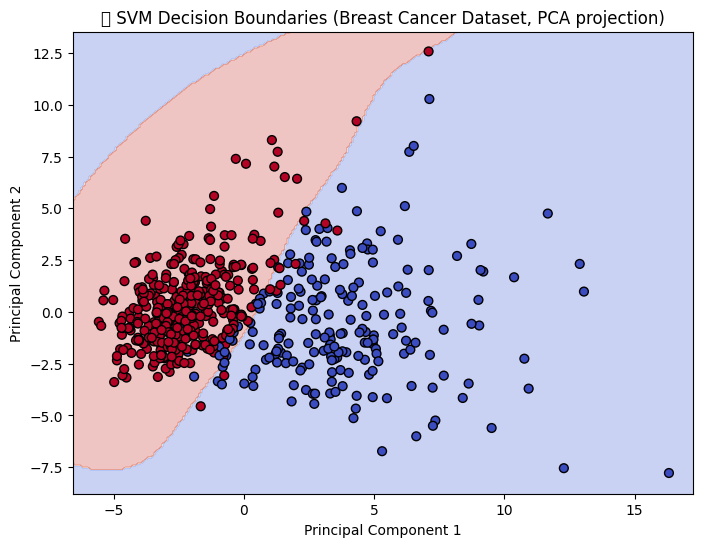

In [9]:
from sklearn.decomposition import PCA

# Reduce data to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train again on reduced data for visualization
svm_pca = SVC(kernel='rbf', C=1, gamma='scale')
svm_pca.fit(X_pca, y)

# Plot decision boundaries
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

#These lines find the minimum and maximum values for both PCA features.
#Subtracting and adding 1 gives some extra space around the edges of the plot, so points don’t touch the boundary.
#Think of it as defining the area (frame) where we’ll draw the decision boundary.

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

#This creates a grid of points (like graph paper) across the entire range of x and y.
#Each point in this grid will be passed through the trained SVM model to see which class it belongs to.
#The result (Z) helps fill the background color showing the decision regions.

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#np.c_[xx.ravel(), yy.ravel()] → Combines all grid coordinates.
#svm_pca.predict(...) → Predicts class for each coordinate.
#.reshape(xx.shape) → Converts predictions back to 2D for plotting.

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=40, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title("🌸 SVM Decision Boundaries (Breast Cancer Dataset, PCA projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


# plt.contourf(...) → Fills the decision regions predicted by your SVM model (Z grid).
# alpha=0.3 → Adds transparency so the points can still be seen.
# plt.scatter(...) → Plots the actual data points (after PCA reduction to 2D).
# c=y → Colors each point according to its flower class.
# edgecolor='k' → Gives black edges to make points clearer.


In [10]:
import joblib
joblib.dump(svm_model,'svm_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']